<a href="https://colab.research.google.com/github/natcha2548/lab-ai-69/blob/main/Explainable.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Thu Sep 10 07:10:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q tf-keras-vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.9 MB/s eta 0:00:00


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

import plotly
import plotly.graph_objs as go
import plotly.figure_factory as ff
import plotly.express as px

# ให้ TensorFlow จอง GPU memory เท่าที่ใช้ เผื่อพื้นที่ให้ MedGemma ในภายหลัง
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!ls /content/drive/MyDrive/XAI

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pcbreviglieri/pneumonia-xray-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pneumonia-xray-images' dataset.
Path to dataset files: /kaggle/input/pneumonia-xray-images


In [10]:
path

'/kaggle/input/pneumonia-xray-images'

In [8]:
os.listdir(path)

['val', 'test', 'train']

In [11]:
train_path = os.path.join(path, 'train')
train_path

'/kaggle/input/pneumonia-xray-images/train'

In [12]:
classes = os.listdir(train_path)
classes

['normal', 'opacity']


Sample image files in 'normal' class:
['NORMAL2-IM-0771-0001.jpeg', 'IM-0675-0001.jpeg', 'IM-0421-0001.jpeg', 'NORMAL2-IM-0531-0001.jpeg', 'NORMAL2-IM-0416-0001-0002.jpeg']

Sample image files in 'opacity' class:
['person1180_virus_2010.jpeg', 'person1230_virus_2081.jpeg', 'person124_virus_238.jpeg', 'person746_virus_1369.jpeg', 'person588_bacteria_2422.jpeg']


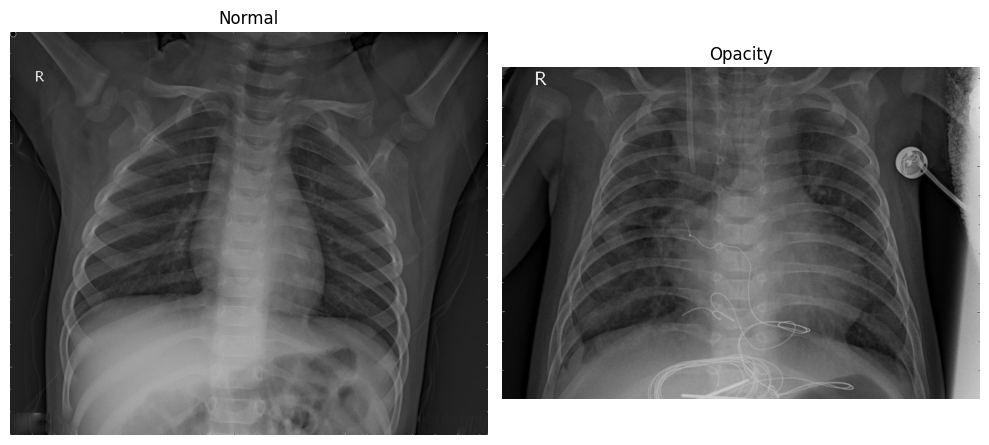

In [13]:
normal_path = os.path.join(train_path, 'normal')
opacity_path = os.path.join(train_path, 'opacity')

print("\nSample image files in 'normal' class:")
print(os.listdir(normal_path)[:5])

print("\nSample image files in 'opacity' class:")
print(os.listdir(opacity_path)[:5])

# Load and display a few sample images
plt.figure(figsize=(10, 5))

# Display a normal image
normal_img_path = os.path.join(normal_path, os.listdir(normal_path)[0])
normal_img = Image.open(normal_img_path)
plt.subplot(1, 2, 1)
plt.imshow(normal_img, cmap='gray')
plt.title('Normal')
plt.axis('off')

# Display an opacity image
opacity_img_path = os.path.join(opacity_path, os.listdir(opacity_path)[0])
opacity_img = Image.open(opacity_img_path)
plt.subplot(1, 2, 2)
plt.imshow(opacity_img, cmap='gray')
plt.title('Opacity')
plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
train_dir = os.path.join(path, 'train')
val_dir   = os.path.join(path, 'val')
test_dir  = os.path.join(path, 'test')

img_size   = (350, 350)
batch_size = 32

# Augmentation สำหรับ Train เท่านั้น — ไม่ใช้ horizontal_flip กับภาพทรวงอก
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    fill_mode='nearest',
)

# Validation / Test ทำแค่ Rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size,
    class_mode='binary', color_mode='grayscale'
)

validation_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size,
    class_mode='binary', color_mode='grayscale'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size,
    class_mode='binary', color_mode='grayscale',
    shuffle=False  # เรียงตามลำดับไฟล์ เพื่อให้จับคู่กับ label ได้ตอน Evaluate
)

Found 4192 images belonging to 2 classes.
Found 1040 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [15]:
batchX, batchY = next(train_generator)
print('Batch shape=%s, min=%.3f, max=%.3f' % (batchX.shape, batchX.min(), batchX.max()))

Batch shape=(32, 350, 350, 1), min=0.000, max=1.000


In [16]:
labels = list(train_generator.class_indices.keys())
labels

['normal', 'opacity']

In [17]:
Counter(train_generator.classes)

Counter({np.int32(0): 1082, np.int32(1): 3110})

In [18]:
weights = compute_class_weight(class_weight = 'balanced', classes = np.unique(train_generator.classes), y = train_generator.classes)
weights

array([1.93715342, 0.67395498])

In [19]:
cw = dict(zip(np.unique(train_generator.classes), weights))
cw

{np.int32(0): np.float64(1.9371534195933457),
 np.int32(1): np.float64(0.6739549839228296)}

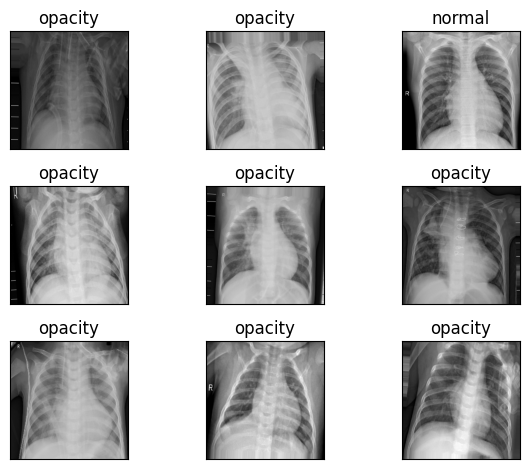

In [20]:
for i in range(9):
    ax = plt.subplot(3, 3, 1+i)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('%s'%(labels[int(batchY[i])]))
    plt.imshow(batchX[i][:,:,0], cmap=plt.get_cmap('gray'))

plt.tight_layout()
plt.savefig('chest_xray.png', dpi=300)

In [21]:
input_shape = (350, 350, 1)

inputs = tf.keras.Input(shape=input_shape)

# Feature Extraction
x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(inputs)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='last_conv_layer')(x)

# Image Classification
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

# Model
model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [27]:
epochs = 5
steps_per_epoch = train_generator.samples // batch_size
first_decay_steps = steps_per_epoch * 10

first_decay_steps

1310

In [23]:
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=0.001,
    first_decay_steps=first_decay_steps,
    t_mul=2.0,           # รอบต่อไปจะใช้เวลายาวขึ้น 2 เท่า
    m_mul=0.9,           # ลด max LR 10% ทุก Restart
    alpha=1e-6           # min LR = alpha × initial LR
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

In [24]:
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 350, 350, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 348, 348, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 174, 174, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 172, 172, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 86, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 84, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 42, 42, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv_layer (Conv2D)        │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,700,897 (25.56 MB)

 Trainable params: 6,700,897 (25.56 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=validation_generator,
    class_weight=cw
)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 76s 577ms/step - accuracy: 0.9680 - loss: 0.0817 - val_accuracy: 0.9740 - val_loss: 0.0745
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 76s 578ms/step - accuracy: 0.9711 - loss: 0.0740 - val_accuracy: 0.9731 - val_loss: 0.0661
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 75s 569ms/step - accuracy: 0.9733 - loss: 0.0722 - val_accuracy: 0.9654 - val_loss: 0.0973
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 74s 568ms/step - accuracy: 0.9516 - loss: 0.1239 - val_accuracy: 0.9702 - val_loss: 0.0916
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 76s 582ms/step - accuracy: 0.9418 - loss: 0.1485 - val_accuracy: 0.9731 - val_loss: 0.0754


In [29]:
loss, accuracy = model.evaluate(test_generator)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 248ms/step - accuracy: 0.8606 - loss: 0.4618
Test Loss: 0.4618
Test Accuracy: 0.8606


In [30]:
h1 = go.Scatter(y=history.history['loss'],
                    mode="lines",
                    line=dict(
                        width=2,
                        color='blue'),
                        name="loss"
                   )
h2 = go.Scatter(y=history.history['val_loss'],
                    mode="lines",
                    line=dict(
                        width=2,
                        color='red'),
                        name="val_loss"
                   )

data = [h1,h2]
layout1 = go.Layout(title='Loss',
                   xaxis=dict(title='epochs'),
                   yaxis=dict(title=''))
fig1 = go.Figure(data, layout=layout1)
plotly.offline.iplot(fig1)

In [31]:
h1 = go.Scatter(y=history.history['accuracy'],
                    mode="lines", line=dict(
                    width=2,
                    color='blue'),
                    name="acc"
                   )
h2 = go.Scatter(y=history.history['val_accuracy'],
                    mode="lines", line=dict(
                    width=2,
                    color='red'),
                    name="val_acc"
                   )

data = [h1,h2]
layout1 = go.Layout(title='Accuracy',
                   xaxis=dict(title='epochs'),
                   yaxis=dict(title=''))
fig1 = go.Figure(data = data, layout=layout1)
plotly.offline.iplot(fig1)

In [32]:
y_score = model.predict(test_generator, verbose=1)[:, 0]
predicted_classes = (y_score > 0.5).astype("int32")


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step


In [33]:
predicted_classes[:10]

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 1], dtype=int32)

In [34]:
test_generator.classes[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [35]:
def cm_plot(cm, labels):
    x = labels
    y = labels

    z_text = [[str(y) for y in x] for x in cm]
    fig = ff.create_annotated_heatmap(cm, x=x, y=y, annotation_text=z_text, colorscale='blues')

    fig.update_layout(title_text='Confusion Matrix')

    fig.add_annotation(dict(font=dict(color="black",size=13),
                            x=0.5,
                            y=-0.15,
                            showarrow=False,
                            text="Predicted Value",
                            xref="paper",
                            yref="paper"
                           ))

    fig.add_annotation(dict(font=dict(color="black",size=13),
                            x=-0.20,
                            y=0.5,
                            showarrow=False,
                            text="Real Value",
                            textangle=-90,
                            xref="paper",
                            yref="paper"
                           ))

    fig.update_layout(margin=dict(t=50, l=200))
    fig['layout']['yaxis']['autorange'] = "reversed"

    fig['data'][0]['showscale'] = True
    fig.show()

In [36]:
Counter(test_generator.classes)

Counter({np.int32(0): 234, np.int32(1): 390})

In [37]:
cm = confusion_matrix(test_generator.classes, predicted_classes)
cm

array([[155,  79],
       [  8, 382]])

In [38]:
cm_plot(cm, labels)

In [39]:
report = classification_report(test_generator.classes, predicted_classes, target_names=labels, digits=4)

print(report)

              precision    recall  f1-score   support

      normal     0.9509    0.6624    0.7809       234
     opacity     0.8286    0.9795    0.8978       390

    accuracy                         0.8606       624
   macro avg     0.8898    0.8209    0.8393       624
weighted avg     0.8745    0.8606    0.8539       624



In [40]:
distribution_df = pd.DataFrame({
    'Score': y_score,
    'Class': pd.Series(test_generator.classes).map({0: 'normal', 1: 'opacity'})
})
distribution_df.sample(5)

,Score,Class
102,0.162585,normal
89,0.164001,normal
353,0.999852,opacity
434,0.985081,opacity
93,0.053376,normal


In [41]:
fig = px.histogram(distribution_df, x='Score', color='Class', nbins=50)
fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.85)

In [43]:
fpr, tpr, threshold = roc_curve(test_generator.classes, y_score)
roc_auc = auc(fpr, tpr)

In [44]:
roc_df = pd.DataFrame(data={'False Positive Rate': fpr, 'True Positive Rate': tpr, 'Threshold': threshold})
roc_df.head()

,False Positive Rate,True Positive Rate,Threshold
0,0.0,0.000000,inf
1,0.0,0.002564,0.999999
2,0.0,0.005128,0.999998
3,0.0,0.015385,0.999997
4,0.0,0.033333,0.999996


In [45]:
def binary_roc_plot(roc_df, roc_auc):
    fig = px.area(
        data_frame=roc_df,
        x='False Positive Rate',
        y='True Positive Rate',
        hover_data=['Threshold'],
        title=f'ROC Curve (AUC={roc_auc:.4f})',
        width=700, height=500,
    )

    fig.add_shape(
        type='line', line=dict(dash='dash'),
        x0=0, x1=1, y0=0, y1=1
    )

    hovertemplate = 'False Positive Rate=%{x:.4f}<br>True Positive Rate=%{y:.4f}<br>Threshold=%{customdata[0]:.4f}'
    fig.update_traces(hovertemplate=hovertemplate)

    fig.show()

In [46]:
binary_roc_plot(roc_df, roc_auc)

In [47]:
path = "/content/drive/MyDrive/XAI/pneumonia_detection_model.keras"

In [48]:
model.save(path)

In [49]:
loaded_model = tf.keras.models.load_model(path)

In [50]:
from transformers import pipeline
import torch
import huggingface_hub

In [60]:
huggingface_hub.login()

In [61]:
pipe = pipeline(
    "image-text-to-text",
    model="google/medgemma-4b-it",
    dtype=torch.bfloat16,
    device="cuda",
)

config.json:   0%|          | 0.00/2.47k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 33.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

/kaggle/input/pneumonia-xray-images/test/opacity/person100_bacteria_475.jpeg


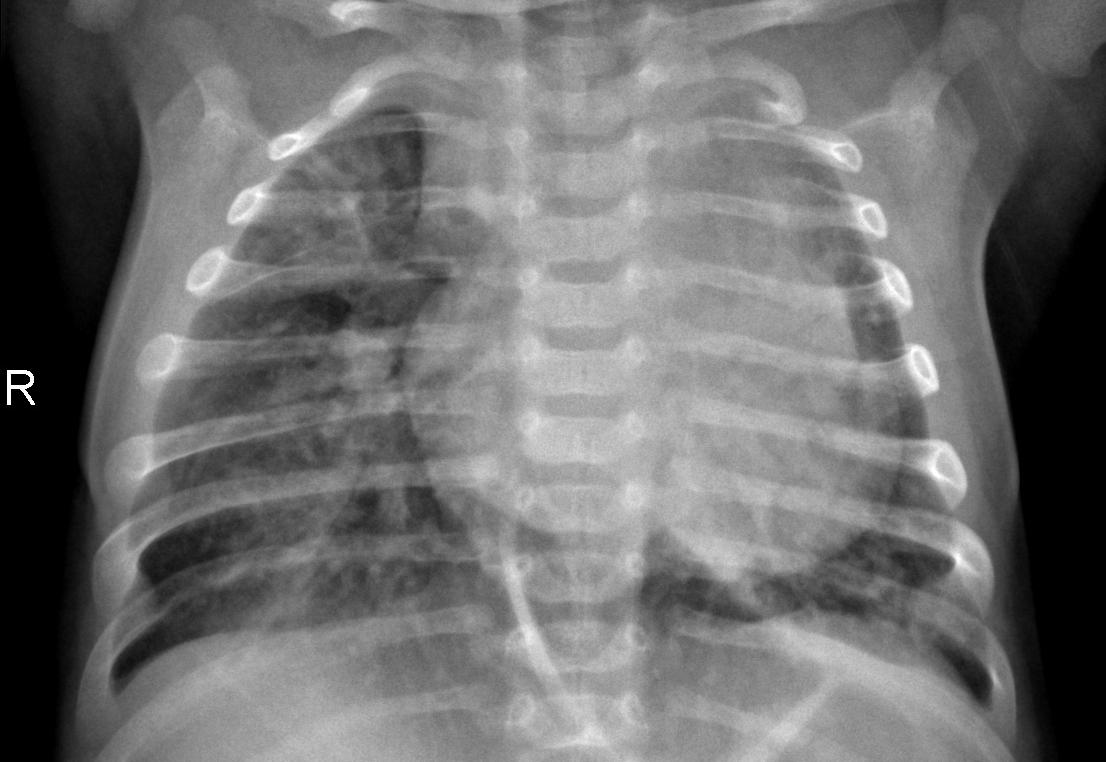

In [62]:
test_classes = test_generator.classes.tolist()
opacity_idx = test_classes.index(1)              # ภาพ opacity ภาพแรก
img_path    = test_generator.filepaths[opacity_idx]
print(img_path)

original_image = Image.open(img_path).convert("RGB")
original_image

In [63]:
prompt_describe = (
    "Describe this chest X-ray. Is there any lung opacity suggestive of pneumonia? "
    "ตอบสั้นกระชับเป็นภาษาไทย ระบุตำแหน่ง (ปอดซ้าย/ขวา บน/ล่าง) ถ้าพบความผิดปกติ"
)

messages = [
    {"role": "system", "content": [{"type": "text", "text": "You are an expert radiologist."}]},
    {"role": "user", "content": [
        {"type": "text", "text": prompt_describe},
        {"type": "image", "image": original_image},   # ส่งภาพต้นฉบับ ไม่ใช่ภาพ 350 px
    ]},
]

output = pipe(text=messages, max_new_tokens=300)
diagnosis = output[0]["generated_text"][-1]["content"]
print(diagnosis)

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'return_dict_in_generate'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


จากภาพที่ให้มา พบว่าปอดขวา (Right Lung) มีความผิดปกติบริเวณส่วนบน (Upper Lung) ซึ่งอาจเป็นภาวะที่ทำให้เกิดความหนาแน่นของเนื้อปอด (Lung Opacity) ซึ่งอาจเกิดจากหลายสาเหตุ เช่น การติดเชื้อ (Pneumonia), การอุดตันของหลอดลม (Bronchial Obstruction), หรือภาวะอื่นๆ

**คำแนะนำ:** ควรมีการตรวจเพิ่มเติม เช่น การถ่ายภาพรังสีทรวงอกในแนวตั้ง (PA Chest X-ray) และการถ่ายภาพรังสีทรวงอกในแนวนอน (Lateral Chest X-ray) เพื่อประเมินความผิดปกติอย่างละเอียด และอาจมีการตรวจเพิ่มเติม เช่น การตรวจเลือด หรือการตรวจปัสสาวะ เพื่อหาสาเหตุของความผิดปกติ

**Disclaimer:** ข้อมูลนี้มีวัตถุประสงค์เพื่อให้ข้อมูลเท่านั้น ไม่ได้มีวัตถุประสงค์เพื่อใช้ในการวินิจฉัยหรือรักษาโรค ควรปรึกษาแพทย์เพื่อการวินิจฉัยและการรักษาที่ถูกต้อง



In [64]:
def preprocess_for_cnn(pil_image, target_size=(350, 350)):
    img = pil_image.convert("L").resize(target_size)          # grayscale + resize ให้ตรงกับ Model
    arr = np.array(img, dtype=np.float32) / 255.0             # normalize 0-1
    return arr.reshape(1, target_size[0], target_size[1], 1)  # (1, 350, 350, 1)

image_array = preprocess_for_cnn(original_image)
image_array.shape

(1, 350, 350, 1)

In [65]:
cnn_prediction = model.predict(image_array)

predicted_class_index = (cnn_prediction > 0.5).astype("int32")[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [66]:
predicted_class_index

np.int32(1)

In [67]:
labels

['normal', 'opacity']

In [68]:
predicted_class_label = labels[predicted_class_index]

print(f"CNN Model Prediction: {predicted_class_label}")
print(f"Prediction Probability: {cnn_prediction[0][0]:.4f}")

CNN Model Prediction: opacity
Prediction Probability: 0.8765


In [69]:
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print(f"Last convolutional layer name: {last_conv_layer_name}")

Last convolutional layer name: last_conv_layer


In [70]:
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

In [71]:
gradcam = Gradcam(model, model_modifier=ReplaceToLinear(), clone=True)

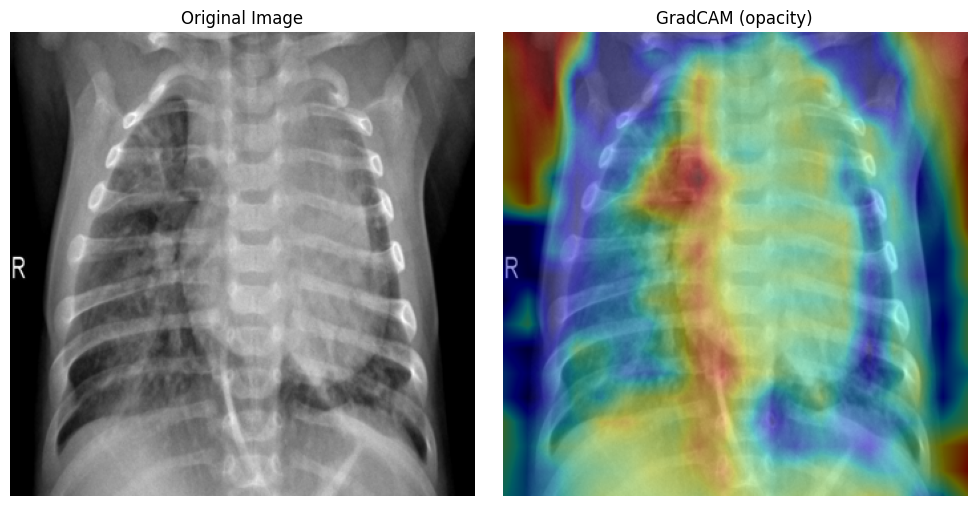

In [72]:
def make_score(predicted_index):
    """Score ที่ตอบคำถามว่า 'ทำไม Model จึงตอบ Class นี้'
    opacity (1): ใช้ logit ตรง ๆ / normal (0): ใช้ logit ติดลบ"""
    if predicted_index == 1:
        return lambda output: output[:, 0]
    return lambda output: -output[:, 0]

heatmap = gradcam(make_score(predicted_class_index),
                  image_array,
                  penultimate_layer=last_conv_layer_name)[0]

# ภาพสำหรับแสดงผล (ย่อให้เท่า input ของ CNN เพื่อซ้อน Heatmap ได้พอดี)
display_image = original_image.resize(img_size)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(display_image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(display_image)
axes[1].imshow(heatmap, cmap='jet', alpha=0.4)
axes[1].set_title(f'GradCAM ({predicted_class_label})')
axes[1].axis('off')

plt.tight_layout()
extent = axes[1].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
fig.savefig('gradcam_heatmap.png', bbox_inches=extent, dpi=300)
plt.show()

In [74]:
heatmap_image = Image.open('gradcam_heatmap.png').convert("RGB")

prompt_explain = (
    f"Image 1 is the original chest X-ray. Image 2 is a GradCAM heatmap from a CNN that "
    f"classified this image as '{predicted_class_label}' (confidence {cnn_prediction[0][0]:.2f}). "
    "Red/yellow areas are where the CNN focused. "
    "อธิบายสั้น ๆ เป็นภาษาไทยว่า บริเวณที่ Model ให้ความสนใจอยู่ตรงส่วนใดของปอด "
    "และสอดคล้องกับความผิดปกติที่เห็นในภาพต้นฉบับหรือไม่ (ไม่ต้องวินิจฉัยใหม่)"
)

messages_with_heatmap = [
    {"role": "system", "content": [{"type": "text", "text": "You are an expert radiologist."}]},
    {"role": "user", "content": [
        {"type": "text", "text": prompt_explain},
        {"type": "image", "image": original_image},
        {"type": "image", "image": heatmap_image},
    ]},
]

output_heatmap = pipe(text=messages_with_heatmap, max_new_tokens=300)
explanation = output_heatmap[0]["generated_text"][-1]["content"]
print(explanation)

[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 GiB. GPU 0 has a total capacity of 14.56 GiB of which 763.81 MiB is free. Including non-PyTorch memory, this process has 13.81 GiB memory in use. Of the allocated memory 8.48 GiB is allocated by PyTorch, and 1.94 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)